In [1]:
import sys
!"{sys.executable}" -m pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 958.5 kB/s eta 0:00:02
   ---------------------------------- ----- 1.8/2.1 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.3 MB/s  0:00:02

   ---------------------------------------- 0/6 [Mako]
   ------ -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
#all imports here
import numpy as np
import pandas as pd
import geohash2
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [3]:
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")



In [4]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [5]:
for col in ['Weather', 'RoadType', 'Landmarks']:
    print(f"\n{col}")
    print(train[col].unique())


Weather
[nan 'Sunny' 'Rainy' 'Foggy' 'Snowy']

RoadType
[nan 'Residential' 'Street' 'Highway']

Landmarks
['No' 'Yes']


In [6]:
train['RoadType'] = train['RoadType'].fillna(train['RoadType'].mode()[0])
train['Weather'] = train['Weather'].fillna(train['Weather'].mode()[0])
train['Temperature'] = train['Temperature'].fillna(train['Temperature'].median())


In [7]:
#test
test_df = test.copy()
test_df['RoadType'] = test_df['RoadType'].fillna(train['RoadType'].mode()[0])
test_df['Weather'] = test_df['Weather'].fillna(train['Weather'].mode()[0])
test_df['Temperature'] = test_df['Temperature'].fillna(train['Temperature'].median())

In [8]:
train['lat'] = train['geohash'].apply(lambda x: geohash2.decode(x)[0])
train['lon'] = train['geohash'].apply(lambda x: geohash2.decode(x)[1])
train['lat'] = pd.to_numeric(train['lat'], errors='coerce')
train['lon'] = pd.to_numeric(train['lon'], errors='coerce')
train['lat_bin'] = pd.qcut(
    train['lat'],
    q=30,
    labels=False,
    duplicates='drop'
)

train['lon_bin'] = pd.qcut(
    train['lon'],
    q=30,
    labels=False,
    duplicates='drop'
)

train['spatial_bin'] = train['lat_bin'].astype(str) + "_" + train['lon_bin'].astype(str)
train['spatial_mean'] = train.groupby('spatial_bin')['demand'].transform('mean')


In [9]:
#test
test_df['lat'] = test_df['geohash'].apply(lambda x: geohash2.decode(x)[0])
test_df['lon'] = test_df['geohash'].apply(lambda x: geohash2.decode(x)[1])

test_df['lat'] = pd.to_numeric(test_df['lat'], errors='coerce')
test_df['lon'] = pd.to_numeric(test_df['lon'], errors='coerce')
lat_bins = np.unique(np.quantile(train['lat'], np.linspace(0,1,31)))
lon_bins = np.unique(np.quantile(train['lon'], np.linspace(0,1,31)))

test_df['lat_bin'] = pd.cut(test_df['lat'], bins=lat_bins, labels=False, include_lowest=True)
test_df['lon_bin'] = pd.cut(test_df['lon'], bins=lon_bins, labels=False, include_lowest=True)

test_df['spatial_bin'] = test_df['lat_bin'].astype(str) + "_" + test_df['lon_bin'].astype(str)

spatial_means = train.groupby(
    train['lat_bin'].astype(str) + "_" + train['lon_bin'].astype(str)
)['demand'].mean()

test_df['spatial_mean'] = test_df['spatial_bin'].map(spatial_means)


In [10]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train['geo_te'] = np.nan

for train_idx, val_idx in kf.split(train):
    tr, val = train.iloc[train_idx], train.iloc[val_idx]
    
    means = tr.groupby('geohash')['demand'].mean()
    train.loc[val_idx, 'geo_te'] = val['geohash'].map(means)


In [11]:
#test
geo_means = train.groupby('geohash')['demand'].mean()
test_df['geo_te'] = test_df['geohash'].map(geo_means)


In [12]:
train['timestamp']=pd.to_datetime(train['timestamp'], format= '%H:%M')
train['hour'] = train['timestamp'].dt.hour
train['minute'] = train['timestamp'].dt.minute

# Convert to total minutes
train['total_minutes'] = train['hour'] * 60 + train['minute']

# Cyclical encoding (full day = 1440 minutes)
train['time_sin'] = np.sin(2 * np.pi * train['total_minutes'] / 1440)
train['time_cos'] = np.cos(2 * np.pi * train['total_minutes'] / 1440)

In [13]:
train['geo_hour_mean'] = train.groupby(['geohash', 'hour'])['demand'] \
                             .shift(1) \
                             .rolling(7) \
                             .mean()

In [14]:
#test
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'], format='%H:%M')

test_df['hour'] = test_df['timestamp'].dt.hour
test_df['minute'] = test_df['timestamp'].dt.minute

test_df['total_minutes'] = test_df['hour'] * 60 + test_df['minute']

test_df['time_sin'] = np.sin(2 * np.pi * test_df['total_minutes'] / 1440)
test_df['time_cos'] = np.cos(2 * np.pi * test_df['total_minutes'] / 1440)

In [15]:
for lag in [1, 2, 3]:
    train[f'lag_{lag}'] = train.groupby('geohash')['demand'].shift(lag)
train['lag_24'] = train.groupby('geohash')['demand'].shift(24)

In [16]:

from sklearn.preprocessing import LabelEncoder

cols=[ 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geohash']

le_dict = {}  # store encoders for each column

for col in cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    le_dict[col] = le

In [17]:
#test
cols = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geohash']

for col in cols:
    le = le_dict[col]
    test_df[col] = test_df[col].map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

In [18]:
train['rolling_mean_3'] = train.groupby('geohash')['demand'] \
                              .shift(1) \
                              .rolling(window=3) \
                              .mean()

train['temp_weather'] = train['Temperature'] * train['Weather']



In [19]:
train['is_hot'] = (train['Temperature'] > 35).astype(int)
train['is_cold'] = (train['Temperature'] < 10).astype(int)

In [20]:
#test
test_df['temp_weather'] = test_df['Temperature'] * test_df['Weather']

test_df['is_hot'] = (test_df['Temperature'] > 35).astype(int)
test_df['is_cold'] = (test_df['Temperature'] < 10).astype(int)

In [21]:

train['diff_1'] = train['lag_1'] - train['lag_2']
train['diff_2'] = train['lag_2'] - train['lag_3']

In [22]:
#test
test_df['orig_index'] = np.arange(len(test_df))

# Sort for sequential prediction
test_df = test_df.sort_values(['geohash', 'time_sin'])

In [23]:
train = train.drop(['Index', 'timestamp','hour','minute', 'total_minutes','Temperature', 'Weather', 'geohash','temp_weather', 
                    'LargeVehicles',
                    'is_hot',
                    'Landmarks',
                    'is_cold',
                    'lat', 'lon',
                    'lat_bin', 
                    'lon_bin',
                    'geo_hour_mean',
                    'spatial_bin',
                    'lag_2', 
                    'lag_3',
                    'time_cos'], axis=1)

In [24]:
#test
drop_cols = ['Index','timestamp','hour','minute','total_minutes','Temperature','Weather','geohash',
             'temp_weather','LargeVehicles','is_hot','Landmarks','is_cold',
             'lat','lon','lat_bin','lon_bin','geo_hour_mean','spatial_bin',
             'lag_2','lag_3','time_cos']

test_df = test_df.drop(drop_cols, axis=1, errors='ignore')

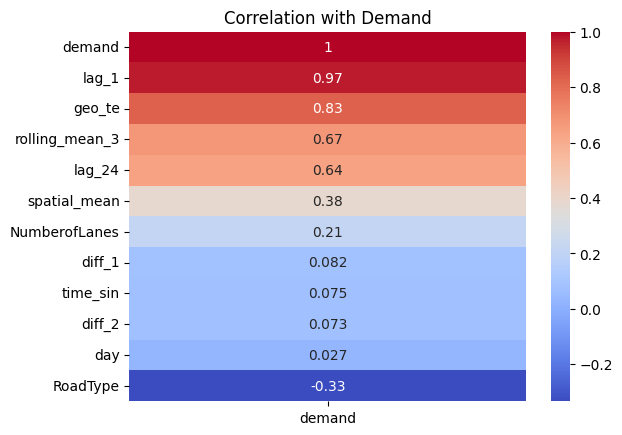

In [25]:
corr_target = train.corr(numeric_only=True)[['demand']]

corr_target = corr_target.sort_values(
    by='demand',
    ascending=False
)

sns.heatmap(corr_target,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation with Demand")
plt.show()

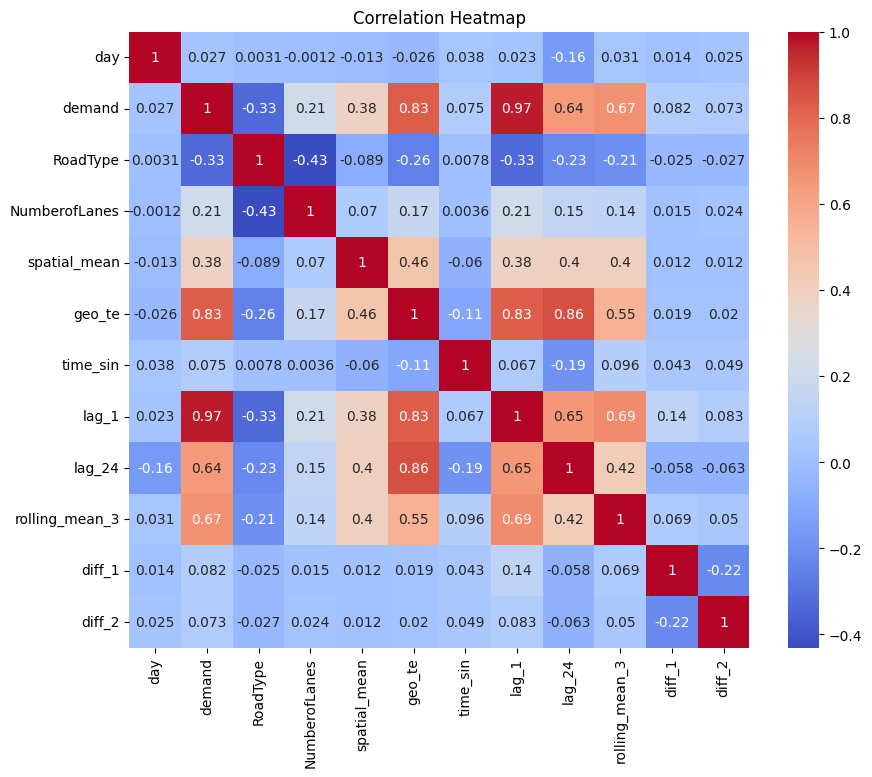

In [26]:

plt.figure(figsize=(10,8))
corr = train.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [27]:
train_48 = train[train['day'] == 48]
train_49 = train[train['day'] == 49]
X_train = train_48.drop('demand', axis=1)
y_train = train_48['demand']

X_val = train_49.drop('demand', axis=1)
y_val = train_49['demand']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

preds_rf = rf.predict(X_val)

r2 = r2_score(y_val, preds_rf)
print(r2)
print("Competition Score:", max(0, 100*r2))

0.9581381716304114
Competition Score: 95.81381716304114


In [28]:
train_48 = train[train['day'] == 48]
train_49 = train[train['day'] == 49]
X_train = train_48.drop('demand', axis=1)
y_train = train_48['demand']

X_val = train_49.drop('demand', axis=1)
y_val = train_49['demand']

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

preds_xgb = xgb.predict(X_val)

r2 = r2_score(y_val, preds_xgb)
print(r2)
print("Competition Score:", max(0, 100*r2))

0.9578747480704974
Competition Score: 95.78747480704975


In [29]:
lgb = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgb.fit(X_train, y_train)
preds_lgb = lgb.predict(X_val)

print(r2_score(y_val, preds_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001123 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1694
[LightGBM] [Info] Number of data points in the train set: 69427, number of used features: 10
[LightGBM] [Info] Start training from score 0.092659
0.95803605231171


In [30]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)
preds_cat = cat.predict(X_val)

print(r2_score(y_val, preds_cat))

0.9605952588908803


In [31]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score

et = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

preds_et = et.predict(X_val)

r2 = r2_score(y_val, preds_et)
print(r2)
print("Competition Score:", max(0, 100*r2))

0.9597464769581661
Competition Score: 95.9746476958166


In [32]:
preds_rf_train = rf.predict(X_train)
preds_et_train = et.predict(X_train)
preds_xgb_train = xgb.predict(X_train)
preds_lgb_train = lgb.predict(X_train)
preds_cat_train = cat.predict(X_train)
train_preds = np.column_stack([
    preds_cat_train,
    preds_et_train,
    preds_rf_train,
    preds_lgb_train,
    preds_xgb_train
])

val_preds = np.column_stack([
    preds_cat,
    preds_et,
    preds_rf,
    preds_lgb,
    preds_xgb
])
from sklearn.linear_model import Ridge

meta = Ridge(alpha=1.0)
meta.fit(train_preds, y_train)

final_preds_stack = meta.predict(val_preds)

r2_stack = r2_score(y_val, final_preds_stack)

print("Stacking R2:", r2_stack)
print("Score:", 100*r2_stack)


Stacking R2: 0.9601901656175633
Score: 96.01901656175633


In [33]:
#weighted avg
final_preds = (
    0.30 * preds_cat +
    0.25 * preds_et +
    0.20 * preds_rf +
    0.15 * preds_lgb +
    0.10 * preds_xgb
)

r2 = r2_score(y_val, final_preds)
print("Weighted R2:", r2)
print("Score:", 100*r2)

Weighted R2: 0.9614783927511421
Score: 96.14783927511421


In [38]:
X_test = test_df
preds_rf  = rf.predict(X_test)
preds_et  = et.predict(X_test)
preds_xgb = xgb.predict(X_test)
preds_lgb = lgb.predict(X_test)
preds_cat = cat.predict(X_test)
final_preds = (
    0.30 * preds_cat +
    0.25 * preds_et +
    0.20 * preds_rf +
    0.15 * preds_lgb +
    0.10 * preds_xgb
)
final_preds = np.clip(final_preds, 0, None)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- orig_index
Feature names seen at fit time, yet now missing:
- diff_1
- diff_2
- lag_1
- lag_24
- rolling_mean_3


In [36]:
submission = pd.DataFrame({
    'id': test['Index'],   # or correct column
    'demand': final_preds
})

submission.to_csv('submission_wtavg.csv', index=False)

ValueError: array length 7872 does not match index length 41778